# 03 - Optimization Space

## What selects one solution?

Optimization space defines how one candidate is selected from the available functions.


Notebook 00 introduced the workshop frame:

$$
\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s.
$$

Notebook 01 unpacked $\mathcal{D}$ as finite evidence. Notebook 02 unpacked $\mathcal{H}$ as the set of explanations the learner is allowed to consider. That left an important gap: a hypothesis space can contain many candidates, and the data do not choose among them by themselves.

This notebook turns to the boxed term using the same solar-panel data:

$$
\mathcal{H}+\mathcal{D}+\boxed{\mathcal{O}}\rightarrow s.
$$

Here $\mathcal{O}$ means the selection machinery: the losses, penalties, numerical solvers, and rules used to compare candidate parameter values and return one selected solution. In this notebook, the selected solution is a fitted parameter vector $\hat{\theta}$ and the corresponding function $h_{\hat{\theta}}$.

The through-line is:

1. keep $\mathcal{D}$ and $\mathcal{H}$ fixed;
2. give each candidate hypothesis a score on the observed measurements;
3. minimise that score to select one $s$;
4. read least squares as a geometric selection rule;
5. change $\mathcal{O}$ by adding a penalty;
6. vary the penalty and watch the selected $s$ move inside the same $\mathcal{H}$;
7. hand the trust and generalisation question to Notebook 04.

Polynomial regression is a useful first case for the power-output curve because the model is linear in $\theta$. Squared-error objectives become quadratic surfaces, so least squares and ridge have closed-form solutions. That lets us see the selection machinery before moving to models where $\mathcal{O}$ is usually iterative and less transparent in future workshops.


<br>

## 1. Learning objectives

These objectives name the skills to practice in this notebook.


By the end, you should be able to:

1. explain why $\mathcal{D}$ and $\mathcal{H}$ do not select a solution by themselves;
2. define a loss as a rule for scoring candidate hypotheses;
3. explain least squares as a selector inside a fixed hypothesis space;
4. distinguish the objective from the numerical solver;
5. explain how adding a ridge penalty changes the selected solution without changing the raw hypothesis space;
6. connect ridge regularisation to MAP estimation at a high level.


<br>

## 2. Session arc

The route isolates the active learning lever in this notebook.


Route:

1. **Abstract:** $\mathcal{O}$ is the machinery that selects one solution.
2. **Concrete:** score candidate lines by squared error.
3. **Inspect:** draw the loss landscape and locate the selected point.
4. **Deepen:** derive least squares and distinguish selector from solver.
5. **Intervene:** add ridge regularisation and vary $\lambda$.
6. Changing $\mathcal{O}$ changes which member of $\mathcal{H}$ becomes $s$.

Use this question throughout:

> What did the optimizer reward, and what kind of solution did that reward select?


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


<br>

## 3. Start From Fixed $\mathcal{D}$ and $\mathcal{H}$

Fixing data and hypotheses lets us study the selector itself.


Begin exactly where Notebook 02 ended. We have one collected dataset,

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n},
$$

and we have chosen a polynomial hypothesis space $\mathcal{H}$ as the family of explanations we are willing to consider. Those choices define the evidence and the menu of possible functions. They still do not choose a fitted model.

A degree-15 polynomial space, for example, contains many curves with very different behaviour between measured panel tilts. The question for this notebook is:

> Given fixed evidence $\mathcal{D}$ and a fixed hypothesis space $\mathcal{H}$, what rule selects one parameter vector $\hat{\theta}$?

For the first pass, do not introduce train/test reasoning. The selector only sees the observed solar-panel calibration evidence $\mathcal{D}$. Notebook 04 will ask whether the selected function should be trusted away from the evidence used to select it.


In [2]:
# Reuse the same evidence controls as Notebook 02.
n_samples = 20
noise_std = 0.20
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"

x_observed, y_observed = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)

# Keep these aliases so later cells read as optimisation over the fitting data.
x_train_opt = x_observed
y_train_opt = y_observed

print_rows(
    [
        {
            "n_samples": n_samples,
            "noise_std": noise_std,
            "sampling": sampling,
            "x_min": np.min(x_train_opt),
            "x_max": np.max(x_train_opt),
        }
    ],
    title="Same fixed evidence as Notebook 02",
)


Same fixed evidence as Notebook 02
01. n_samples=20, noise_std=0.2000, sampling=uniform, x_min=0.1774, x_max=0.9670


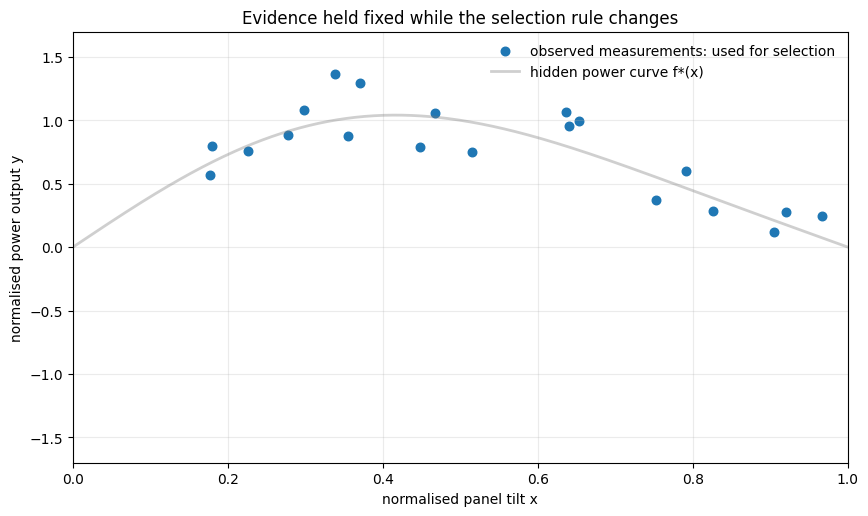

In [3]:
# Visualise the fixed evidence used by the optimizer.
x_grid = data.make_test_grid(n_points=500)
fig, ax = plt.subplots(figsize=(10.0, 5.6))
ax.scatter(x_train_opt, y_train_opt, s=38, color="#1f77b4", label="observed measurements: used for selection")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
ax.set_title("Evidence held fixed while the selection rule changes")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


<br>

## 4. Give Each Candidate a Score

A loss function defines what kind of error the selector cares about.


A selection rule first needs a way to compare candidates. Start with the degree-1 space:

$$
h_\theta(x)=\theta_0+\theta_1x.
$$

Each point $(\theta_0,\theta_1)$ is one straight-line power-output rule. To score it, predict the observed responses, compute residuals, and reduce them to one number.

Mean squared error is one common score:

$$
\mathcal{L}_{\mathcal{D}}(\theta)=\frac{1}{n}\sum_{(x_i,y_i)\in\mathcal{D}}(y_i-h_\theta(x_i))^2.
$$

The score is not the truth. It is the comparison rule used by $\mathcal{O}$.

Other scores express other priorities. If $e_i=y_i-h_\theta(x_i)$, examples include:

$$
\text{MAE}(\theta)=\frac{1}{n}\sum_i |e_i|,
\qquad
\text{MaxError}(\theta)=\max_i |e_i|,
\qquad
\text{WeightedMSE}(\theta)=\frac{1}{n}\sum_i w_i e_i^2.
$$

MSE punishes large misses. MAE treats extra residual size more evenly. Max error focuses on the worst calibration miss. A weighted score can make some solar-power errors, such as over-predicted power output, more costly.

Changing the score can change the selected $\theta$ while $\mathcal{H}$ and $\mathcal{D}$ stay fixed. The next cell scores a few hand-written lines before the optimizer chooses.


### 4.1 Before running: score is not truth

The next cell scores several hand-written candidate lines. The score is not the model and it is not the truth. It is a rule for comparing candidates.

Before running, predict which candidate will have the smallest MSE and which will miss the power readings most badly.


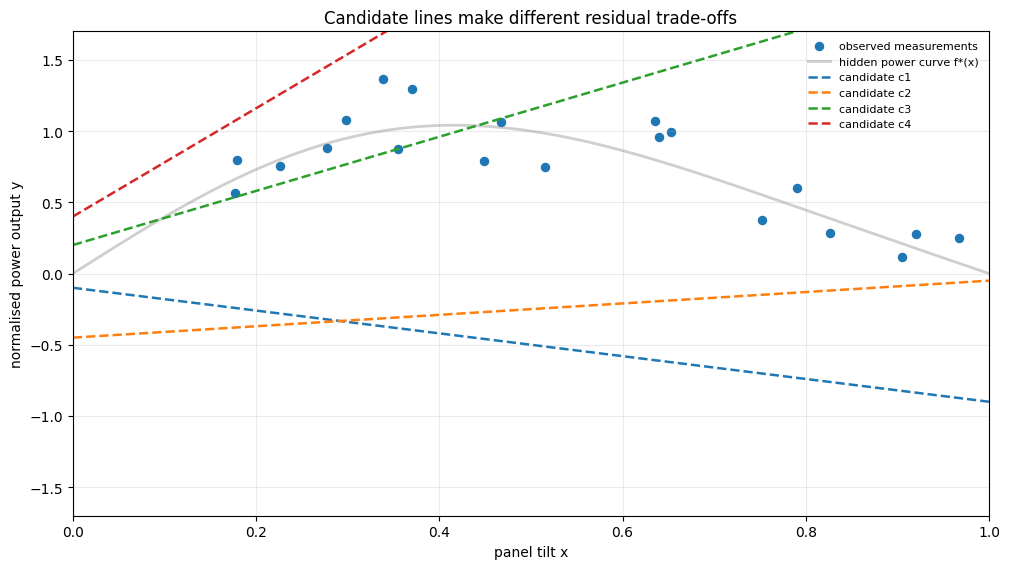

Candidate degree-1 theta values under several scores
01. candidate=c1, theta_0=-0.1000, theta_1=-0.8000, train_mse=1.7271, train_mae=1.2868, max_abs_residual=1.7377, over_output_weighted_mse=1.7271
02. candidate=c2, theta_0=-0.4500, theta_1=0.4000, train_mse=1.1603, train_mae=0.9922, max_abs_residual=1.6811, over_output_weighted_mse=1.1603
03. candidate=c3, theta_0=0.2000, theta_1=1.9000, train_mse=0.7822, train_mae=0.6434, max_abs_residual=1.8018, over_output_weighted_mse=3.7845
04. candidate=c4, theta_0=0.4000, theta_1=3.8000, train_mse=4.3152, train_mae=1.6842, max_abs_residual=3.8264, over_output_weighted_mse=21.5758
Different scores can prefer different candidates
01. selector=MSE selector, chosen_candidate=c3, score_used=train_mse, score_value=0.7822
02. selector=MAE selector, chosen_candidate=c3, score_used=train_mae, score_value=0.6434
03. selector=worst-miss selector, chosen_candidate=c2, score_used=max_abs_residual, score_value=1.6811
04. selector=over-predicted weighted sele

In [4]:
# Score a few candidate lines before asking an optimizer to choose.
candidate_thetas = [(-0.1, -0.8), (-0.45, 0.4), (0.2, 1.9), (0.4, 3.8)]
candidate_rows = []

fig, ax = plt.subplots(figsize=(10.2, 5.8))
ax.scatter(x_train_opt, y_train_opt, s=34, color="#1f77b4", label="observed measurements")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")

for idx, (theta0, theta1) in enumerate(candidate_thetas, start=1):
    train_pred = theta0 + theta1 * x_train_opt
    grid_pred = theta0 + theta1 * x_grid
    residuals = y_train_opt - train_pred
    over_output_weights = np.where(train_pred > y_train_opt, 5.0, 1.0)
    candidate_rows.append(
        {
            "candidate": f"c{idx}",
            "theta_0": theta0,
            "theta_1": theta1,
            "train_mse": metrics.mse(y_train_opt, train_pred),
            "train_mae": np.mean(np.abs(residuals)),
            "max_abs_residual": np.max(np.abs(residuals)),
            "over_output_weighted_mse": np.mean(over_output_weights * residuals**2),
        }
    )
    ax.plot(x_grid, grid_pred, linestyle="--", linewidth=1.8, label=f"candidate c{idx}")

ax.set_title("Candidate lines make different residual trade-offs")
ax.set_xlabel("panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.7, 1.7)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
show_fig(fig)

score_columns = {
    "MSE selector": "train_mse",
    "MAE selector": "train_mae",
    "worst-miss selector": "max_abs_residual",
    "over-predicted weighted selector": "over_output_weighted_mse",
}
selector_rows = []
for selector_name, score_name in score_columns.items():
    winner = min(candidate_rows, key=lambda row: row[score_name])
    selector_rows.append(
        {
            "selector": selector_name,
            "chosen_candidate": winner["candidate"],
            "score_used": score_name,
            "score_value": winner[score_name],
        }
    )

print_rows(candidate_rows, title="Candidate degree-1 theta values under several scores")
print_rows(selector_rows, title="Different scores can prefer different candidates")


### 4.2 After running: read the score as selection pressure

Inspect the residuals and the score table as power-output errors at measured tilt settings.

- Which candidate looked best under MSE?
- Did the same candidate look best under MAE, worst-case error, and the over-predicted weighted score?
- What solar-power calibration priority does each score imply?
- Did we change $\mathcal{H}$, $\mathcal{D}$, or only the way candidates were scored?

A loss function turns model fitting into a comparison problem. It defines what kind of mistake the optimizer cares about, so it can change the selected solution even when the data and hypothesis space are unchanged.


<br>

## 5. Turn Scores Into a Selector

Minimisation turns candidate scores into a chosen parameter value.


Scoring candidates is not yet learning. The selection step chooses the parameter value with the smallest score.

For least squares, the selector is:

$$
\mathcal{O}_{\mathrm{LS}}(\mathcal{D}) = \operatorname*{arg\,min}_{\theta\in\Theta}\,\mathcal{L}_{\mathcal{D}}(\theta).
$$

A selector can be implemented in several ways:

- evaluate a finite shortlist and choose the best observed candidate;
- scan a grid or random sample of parameter values;
- solve a closed-form equation when the objective makes that possible;
- use an iterative solver such as gradient descent;
- add constraints or tie-breakers, such as preferring smaller coefficients among equally good fits.

These choices are not just software details. They define what it means to select a solution. For the solar-panel tilt, one selector might choose the line with the smallest average squared power output error, while another might choose the line whose worst miss is smallest or whose over-predicted power output are rare. Both selectors use the same evidence and the same candidate family, but they express different problem priorities.

For a two-parameter line, we can draw the score assigned to each possible $\theta$. With a full-rank degree-1 design matrix, the least-squares surface is a strict convex quadratic bowl with one selected point. If the design matrix is rank deficient, least squares remains convex, but flat directions can make the selected $\theta$ non-unique.

The hand-written `candidate_thetas` are only reference points on this surface. Least squares is not choosing the best one from that short list; it is searching the full parameter space $\Theta$ for the lowest score.


### 5.1 Before running: from scoring to selecting

Scoring a few hand-written candidates is not yet optimization. Least squares searches the whole parameter space for the lowest score.

A loss landscape is the map:

$$
\theta \longmapsto \mathcal{L}_{\mathcal{D}}(\theta).
$$

For the straight-line power-output model, the horizontal coordinates are $\theta_0$ and $\theta_1$. The height or colour at each point is the score assigned to that particular line. The optimizer is a way to explore or solve this landscape so that it can return the lowest-scoring point.

Before running, predict where the bottom of the bowl will sit relative to the hand-written candidates. Then ask:

> If we removed one hand-written candidate from the display, would the least-squares solution move? Why or why not?

The next cell draws the same loss landscape two ways: a 3D surface to show the bowl, and a 2D contour map to show the selected coordinates clearly.


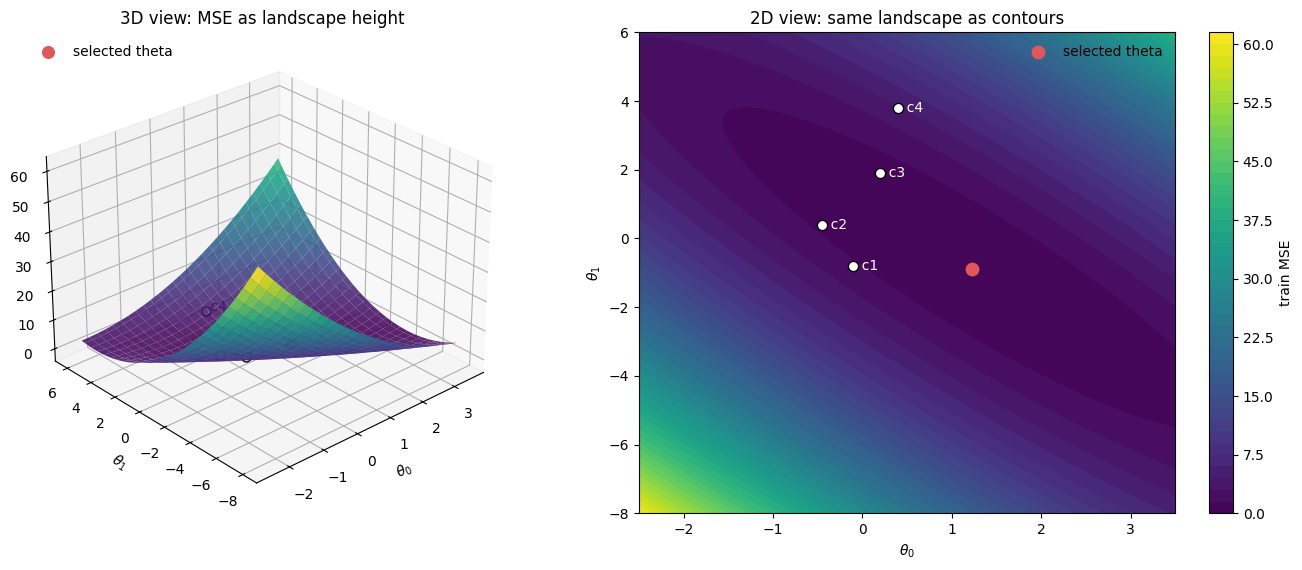

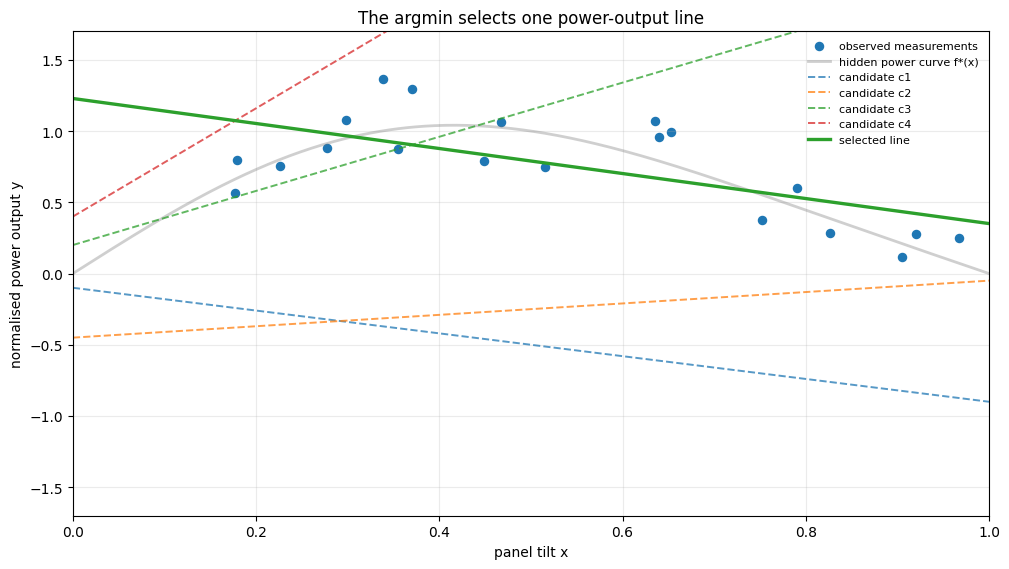

Theta selected by least squares
01. theta_0=1.2286, theta_1=-0.8779, train_mse=0.0709


In [5]:
# Draw the degree-1 loss landscape and the theta selected by least squares.
theta0_values = np.linspace(-2.5, 3.5, 160)
theta1_values = np.linspace(-8.0, 6.0, 160)
Theta0, Theta1 = np.meshgrid(theta0_values, theta1_values)

# Use wider parameter bounds so the full quadratic basin is visible around the selected point.

loss_surface = np.empty_like(Theta0)
for row in range(Theta0.shape[0]):
    for col in range(Theta0.shape[1]):
        pred = Theta0[row, col] + Theta1[row, col] * x_train_opt
        loss_surface[row, col] = metrics.mse(y_train_opt, pred)

coeffs_line = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=1)
selected_line = models.predict_polynomial(x_grid, coeffs_line)
selected_train_mse = metrics.mse(y_train_opt, models.predict_polynomial(x_train_opt, coeffs_line))
candidate_losses = [
    metrics.mse(y_train_opt, theta0 + theta1 * x_train_opt)
    for theta0, theta1 in candidate_thetas
]

fig_landscape = plt.figure(figsize=(14.2, 5.8))
ax_surface = fig_landscape.add_subplot(1, 2, 1, projection="3d")
stride = 3
ax_surface.plot_surface(
    Theta0[::stride, ::stride],
    Theta1[::stride, ::stride],
    loss_surface[::stride, ::stride],
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.88,
)
for idx, ((theta0, theta1), loss_value) in enumerate(zip(candidate_thetas, candidate_losses), start=1):
    ax_surface.scatter(theta0, theta1, loss_value, color="white", edgecolor="black", s=42)
    ax_surface.text(theta0, theta1, loss_value, f" c{idx}", color="black")
ax_surface.scatter(coeffs_line[0], coeffs_line[1], selected_train_mse, color="#e15759", s=70, label="selected theta")
ax_surface.set_title("3D view: MSE as landscape height")
ax_surface.set_xlabel(r"$\theta_0$")
ax_surface.set_ylabel(r"$\theta_1$")
ax_surface.set_zlabel("train MSE")
ax_surface.view_init(elev=28, azim=-132)
ax_surface.legend(frameon=False, loc="upper left")

ax_contour = fig_landscape.add_subplot(1, 2, 2)
contour = ax_contour.contourf(Theta0, Theta1, loss_surface, levels=50, cmap="viridis")
for idx, (theta0, theta1) in enumerate(candidate_thetas, start=1):
    ax_contour.scatter(theta0, theta1, color="white", edgecolor="black", s=54)
    ax_contour.text(theta0, theta1, f"  c{idx}", color="white", va="center")
ax_contour.scatter(coeffs_line[0], coeffs_line[1], color="#e15759", s=80, label="selected theta")
ax_contour.set_title("2D view: same landscape as contours")
ax_contour.set_xlabel(r"$\theta_0$")
ax_contour.set_ylabel(r"$\theta_1$")
ax_contour.legend(frameon=False)
fig_landscape.colorbar(contour, ax=ax_contour, label="train MSE")
fig_landscape.tight_layout()
show_fig(fig_landscape)

fig_curve, ax_curve = plt.subplots(figsize=(10.2, 5.8))
ax_curve.scatter(x_train_opt, y_train_opt, s=34, color="#1f77b4", label="observed measurements")
ax_curve.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
for idx, (theta0, theta1) in enumerate(candidate_thetas, start=1):
    ax_curve.plot(x_grid, theta0 + theta1 * x_grid, linestyle="--", linewidth=1.4, alpha=0.75, label=f"candidate c{idx}")
ax_curve.plot(x_grid, selected_line, color="#2ca02c", linewidth=2.4, label="selected line")
ax_curve.set_title("The argmin selects one power-output line")
ax_curve.set_xlabel("panel tilt x")
ax_curve.set_ylabel("normalised power output y")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-1.7, 1.7)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8)
fig_curve.tight_layout()
show_fig(fig_curve)

print_rows(
    [{"theta_0": coeffs_line[0], "theta_1": coeffs_line[1], "train_mse": selected_train_mse}],
    title="Theta selected by least squares",
)


### 5.2 After running: interpret the loss landscape

Read the contour plot before reading the equations.

- Every point in the landscape is one parameter vector.
- The height or colour is the loss assigned by $\mathcal{O}$.
- The hand-written candidates are only landmarks on the landscape.
- The selected point is the bottom of the bowl.

The optimizer is not choosing from the few examples we drew. It is selecting the lowest-scoring power-output rule in the available parameter space.


### 5.3 Extension: when the selector has a formula

The rest of this section unpacks least squares because this particular objective has unusually clean mathematics. Squared error with a model that is linear in its parameters produces a quadratic bowl, and the bottom of that bowl can be written as a closed-form equation.

That is useful for learning the geometry, but it is not the usual situation for every model. Many later objectives have no convenient closed-form selector, so $\mathcal{O}$ must rely on an iterative algorithm. The conceptual role stays the same: define a score, search or solve the resulting landscape, and return one selected parameter vector.


### 5.4 Mathematical unpacking: why the bowl has a selected point

The contour plot gave the visual story. The equations explain the bottom of the least-squares bowl: at the selected point, no small change to the parameters reduces the squared-error score.

Stack the feature rows for the observed measurements into a design matrix $\Phi$. The prediction vector is $\hat{y}=\Phi\theta$, and the residual vector is:

$$
r(\theta)=\Phi\theta-y.
$$

Use residual sum of squares for the algebra:

$$
\mathcal{L}_{\mathcal{D}}(\theta)=\lVert \Phi\theta-y\rVert_2^2.
$$

This selects the same $\hat{\theta}$ as MSE because dividing the whole objective by $n$ does not change which value is smallest.

For this quadratic objective, the slope with respect to the parameters is:

$$
\nabla_\theta \mathcal{L}_{\mathcal{D}}(\theta)=2\Phi^\top(\Phi\theta-y).
$$

Setting that slope to zero gives the **normal equations**:

$$
\Phi^\top\Phi\theta=\Phi^\top y.
$$

If the columns of $\Phi$ are independent, $\Phi^\top\Phi$ is invertible, so there is one least-squares selector:

$$
\hat{\theta}=(\Phi^\top\Phi)^{-1}\Phi^\top y.
$$

Plainly: least squares keeps adjusting the line until no small change to the intercept or slope would reduce the squared errors. The selected line is not necessarily scientifically true; it is the line that best satisfies this particular score on this particular dataset.


<br>

## 6. Check What Least Squares Selected

The least-squares equations describe the point the score selects.


The previous picture used a grid because there were only two parameters. For a larger polynomial space, drawing every possible $\theta$ is no longer practical, but the same objects are still present.

For a polynomial basis, collect all feature rows from $\mathcal{D}$ into a design matrix $\Phi$:

$$
\Phi = \begin{bmatrix}
\phi(x_1)^\top \\
\phi(x_2)^\top \\
\vdots \\
\phi(x_n)^\top
\end{bmatrix}.
$$

Each row belongs to one observation. Each column is one reusable feature shape from Notebook 02: $1$, $x$, $x^2$, and so on. The parameter vector $\theta$ mixes those columns, producing all training predictions at once:

$$
\hat{y}=\Phi\theta.
$$

The least-squares condition

$$
\Phi^\top(\Phi\hat{\theta}-y)=0
$$

says that every feature column has zero dot product with the final residual vector. In plainer language: after fitting, none of the available feature shapes can explain a remaining one-step pattern in the errors.

Another way to say this: if the residuals still lined up with the column $x^2$, then adding a little more $x^2$ would improve the fit. At the least-squares solution, every available column has already been used as much as this score can justify.

The next cells check that story numerically and visually for a degree-3 power-output polynomial. The table compares the normal-equation solution with the stable numerical least-squares helper, then prints the feature-residual dot products that should be near zero. The plot turns those near-zero dot products into a diagnostic picture.

Read this as a check on $\mathcal{O}$: did the least-squares selector reach the point it intended to select? This is not a new data choice and not a new hypothesis-space choice.


In [6]:
# Compare the normal-equation view with the numerical least-squares helper.
closed_degree = 3
Phi = models.polynomial_features(x_train_opt, degree=closed_degree)
gram_matrix = Phi.T @ Phi
rhs_vector = Phi.T @ y_train_opt

coeffs_normal = np.linalg.solve(gram_matrix, rhs_vector)
coeffs_lstsq = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=closed_degree)
max_abs_difference = np.max(np.abs(coeffs_normal - coeffs_lstsq))
residuals_lstsq = Phi @ coeffs_lstsq - y_train_opt
feature_residual_dots = Phi.T @ residuals_lstsq

print_rows(
    [
        {"object": "Phi", "shape": Phi.shape},
        {"object": "rank(Phi)", "value": np.linalg.matrix_rank(Phi)},
        {"object": "cond(Phi)", "value": np.linalg.cond(Phi)},
        {"object": "cond(Phi.T @ Phi)", "value": np.linalg.cond(gram_matrix)},
        {"object": "max_abs_difference", "value": max_abs_difference},
        {"object": "max_abs_feature_residual_dot", "value": np.max(np.abs(feature_residual_dots))},
        {"object": "residual_norm", "value": np.linalg.norm(residuals_lstsq)},
    ],
    title="Closed-form least-squares mechanics",
)
print_rows(
    [{"feature": f"x^{idx}", "theta": value, "feature_dot_residual": feature_residual_dots[idx]} for idx, value in enumerate(coeffs_lstsq)],
    title=f"Selected degree-{closed_degree} theta values and stationarity check",
)

Closed-form least-squares mechanics
01. object=Phi, shape=(20, 4)
02. object=rank(Phi), value=4
03. object=cond(Phi), value=236.1409
04. object=cond(Phi.T @ Phi), value=5.58e+04
05. object=max_abs_difference, value=1.30e-11
06. object=max_abs_feature_residual_dot, value=3.44e-14
07. object=residual_norm, value=0.7755
Selected degree-3 theta values and stationarity check
01. feature=x^0, theta=-0.4023, feature_dot_residual=-3.44e-14
02. feature=x^1, theta=8.3093, feature_dot_residual=-1.70e-14
03. feature=x^2, theta=-13.8753, feature_dot_residual=-1.07e-14
04. feature=x^3, theta=6.0777, feature_dot_residual=-7.85e-15


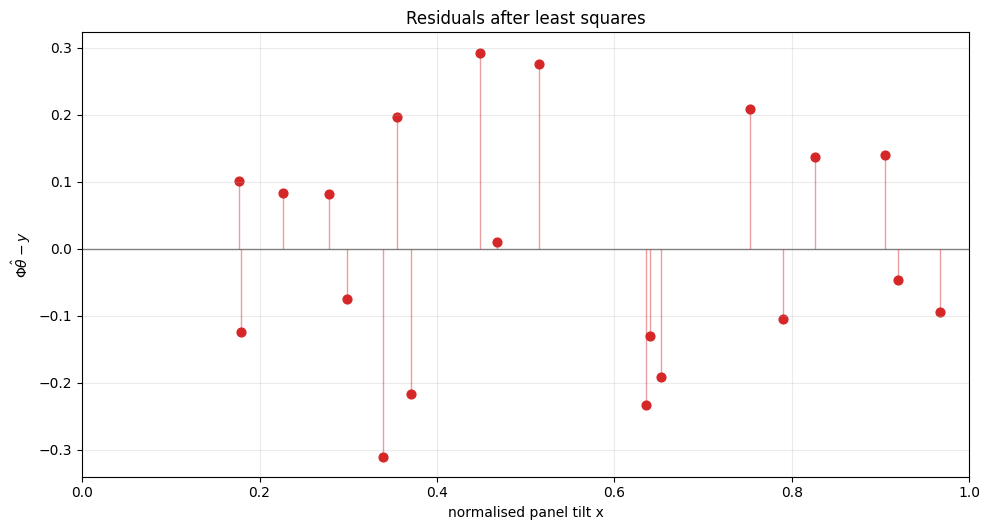

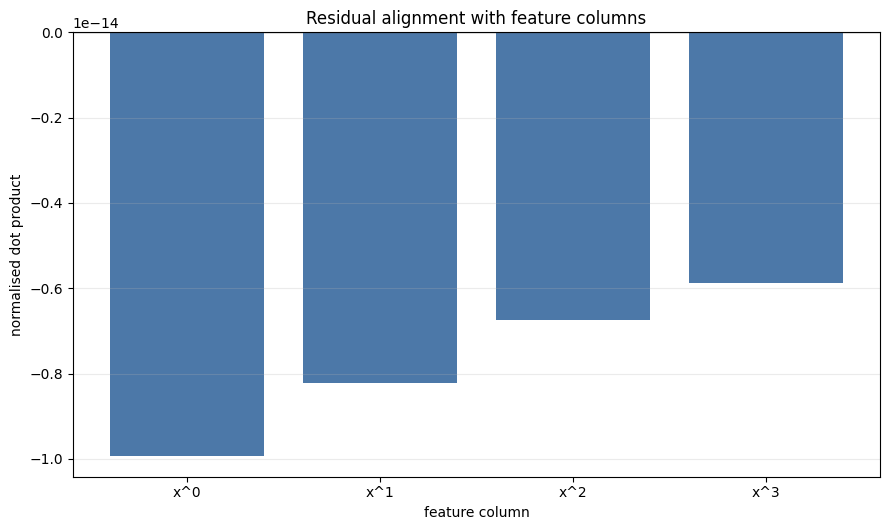

In [7]:
# Visualise the residual geometry behind the normal equations.
feature_names = [f"x^{idx}" for idx in range(Phi.shape[1])]
residual_norm = np.linalg.norm(residuals_lstsq)
feature_norms = np.linalg.norm(Phi, axis=0)
scaled_feature_alignment = feature_residual_dots / np.maximum(feature_norms * residual_norm, 1e-12)

fig_residuals, ax_residuals = plt.subplots(figsize=(10.0, 5.4))
ax_residuals.axhline(0.0, color="#555555", linewidth=1.0, alpha=0.7)
ax_residuals.scatter(x_train_opt, residuals_lstsq, s=40, color="#d62728")
ax_residuals.vlines(x_train_opt, 0.0, residuals_lstsq, color="#d62728", alpha=0.45, linewidth=1.0)
ax_residuals.set_title("Residuals after least squares")
ax_residuals.set_xlabel("normalised panel tilt x")
ax_residuals.set_ylabel(r"$\Phi\hat{\theta}-y$")
ax_residuals.set_xlim(0.0, 1.0)
ax_residuals.grid(alpha=0.25)
fig_residuals.tight_layout()
show_fig(fig_residuals)

fig_alignment, ax_alignment = plt.subplots(figsize=(9.0, 5.4))
ax_alignment.axhline(0.0, color="#555555", linewidth=1.0, alpha=0.7)
ax_alignment.bar(feature_names, scaled_feature_alignment, color="#4c78a8")
ax_alignment.set_title("Residual alignment with feature columns")
ax_alignment.set_xlabel("feature column")
ax_alignment.set_ylabel("normalised dot product")
ax_alignment.grid(axis="y", alpha=0.25)
fig_alignment.tight_layout()
show_fig(fig_alignment)


<br>

## 7. Separate the Selector From the Solver

The objective says what to select; the solver determines how reliably we get there.


The equation

$$
\Phi^\top\Phi\theta=\Phi^\top y
$$

describes the selected least-squares point. It is not always the best computational route to that point.

Forming $\Phi^\top\Phi$ roughly squares the condition number of $\Phi$, which can magnify numerical error for high-degree monomial features. Production least-squares code commonly uses QR or singular-value decompositions through routines such as `np.linalg.lstsq`.

This distinction belongs inside $\mathcal{O}$. The objective says what should be selected; the numerical algorithm determines how reliably the intended selector is reached. In workshop language, the available features in $\mathcal{H}$ and the observed evidence $\mathcal{D}$ have not changed, but the implementation of the selection machinery matters.

Notebook 02 showed another way to improve conditioning: use different coordinates for the same polynomial function space, such as shifted Chebyshev features instead of raw monomial powers. That does not necessarily change which functions live in $\mathcal{H}$, but it can make the numerical search more stable because the feature columns are less redundant and less extreme over the tilt-setting range.

For this notebook, keep the distinction simple: $\mathcal{H}$ says what functions are possible; the solver is part of $\mathcal{O}$ and says how reliably we reach the selected function under the chosen score.


<br>

## 8. Change $\mathcal{O}$: Add a Penalty

Regularisation changes preferences over solutions without changing the data or hypothesis space.


Notebook 02 showed the problem with rich spaces. Lowering polynomial degree would change $\mathcal{H}$. Regularisation keeps $\mathcal{H}$ fixed and changes what the selector prefers.

In a degree-$d$ monomial basis, the observed panel tilts form

$$
\Phi=
\begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
\vdots & \vdots & \vdots & & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^d
\end{bmatrix}.
$$

As $d$ grows, columns such as $x^8,x^9,x^{10}$ can be highly correlated on the observed interval. With

$$
\Phi=U\Sigma V^\top,
$$

a small singular value $\sigma_j$ gives a direction $v_j$ where

$$
\lVert\Phi v_j\rVert_2=\sigma_j\lVert v_j\rVert_2.
$$

If $\sigma_j$ is tiny, a large coefficient change along $v_j$ barely changes fitted values at the observed rows:

$$
\Phi(\theta+c v_j)=\Phi\theta+c\Phi v_j,
\qquad
\lVert c\Phi v_j\rVert_2=|c|\sigma_j.
$$

Those are the large cancelling coefficient directions. Least squares amplifies them because

$$
\hat{\theta}_{\mathrm{LS}}=V\Sigma^{-1}U^\top y,
$$

so small-$\sigma_j$ directions are multiplied by $1/\sigma_j$.

Weight decay, or ridge regularisation, adds a price for large non-intercept coefficients:

$$
J_\lambda(\theta)=\underbrace{\lVert\Phi\theta-y\rVert_2^2}_{\text{data fit}}+
\underbrace{\lambda_{\mathrm{RSS}}\lVert R\theta\rVert_2^2}_{\text{coefficient penalty}}.
$$

Here $R=\operatorname{diag}(0,1,1,\ldots,1)$. Larger $\lambda_{\mathrm{RSS}}$ raises the price of coefficient size; smaller $\lambda_{\mathrm{RSS}}$ behaves more like ordinary least squares.

Ridge chooses

$$
\hat{\theta}_\lambda=(\Phi^\top\Phi+\lambda_{\mathrm{RSS}}R^\top R)^{-1}\Phi^\top y.
$$

If all coefficients were penalised equally, the SVD shrinkage factor would be

$$
\frac{\sigma_j}{\sigma_j^2+\lambda}
$$

instead of $1/\sigma_j$. That is the key effect: ridge reduces weak-direction amplification without removing the building blocks from $\mathcal{H}$.


### 8.1 Extension: notation, scaling, and probability view

This subsection is optional. The main point is simple: ridge keeps $\mathcal{H}$ and $\mathcal{D}$ fixed, but changes $\mathcal{O}$ so coefficient-heavy explanations cost more.

The cells use an RSS-scaled objective:

$$
\text{RSS}+\lambda_{\mathrm{RSS}}\lVert R\theta\rVert_2^2.
$$

If you write the objective with MSE instead,

$$
\text{MSE}+\lambda_{\mathrm{MSE}}\lVert R\theta\rVert_2^2,
$$

then the same solution uses

$$
\lambda_{\mathrm{MSE}}=\frac{\lambda_{\mathrm{RSS}}}{n}.
$$

Multiplying the whole objective by a positive constant does not change the selected curve. Rescaling only the data term changes the number attached to `lambda`.

For a two-parameter line, the penalty adds $\lambda_{\mathrm{RSS}}\theta_1^2$ to the landscape. The next plot shows steep slopes becoming expensive as $\lambda_{\mathrm{RSS}}$ grows.

**Optional probability side note.** With Gaussian residuals, squared error is proportional to negative log-likelihood. With a zero-centred Gaussian prior on non-intercept coefficients, the ridge penalty is proportional to negative log-prior. Minimising squared error plus ridge is therefore a MAP estimate:

$$
\hat{\theta}_{\mathrm{MAP}}=\operatorname*{arg\,max}_\theta p(\mathcal{D}\mid\theta)p(\theta).
$$


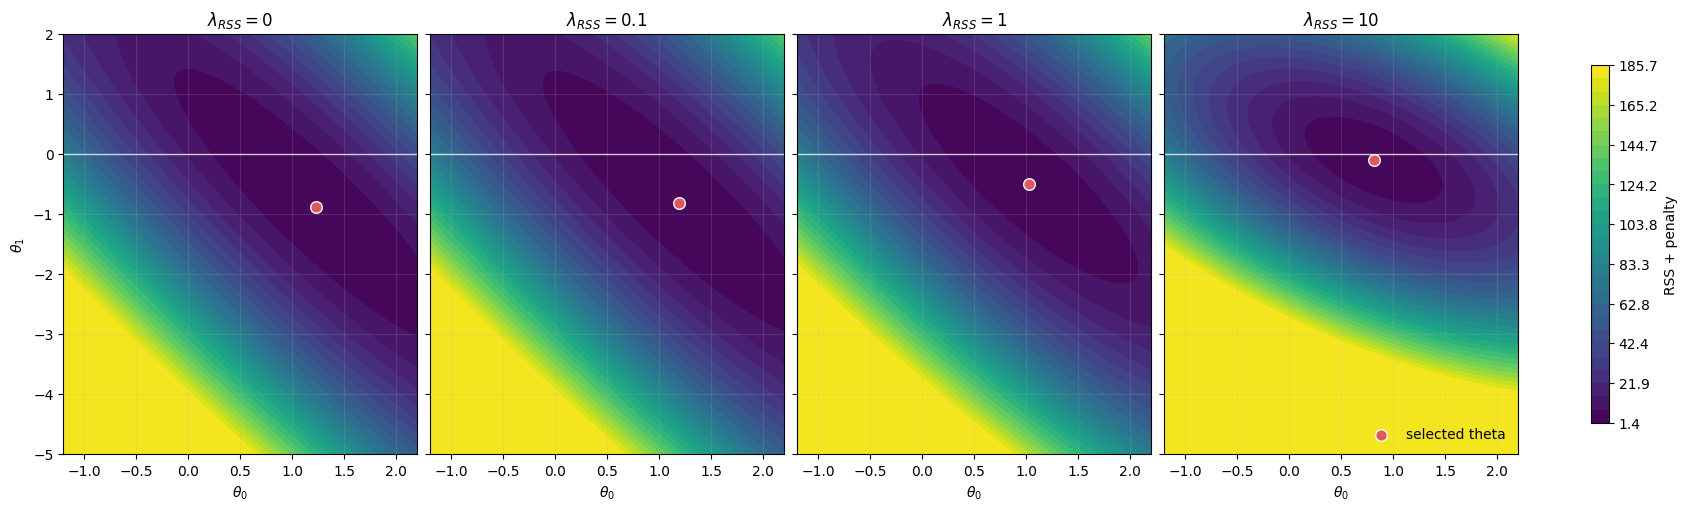

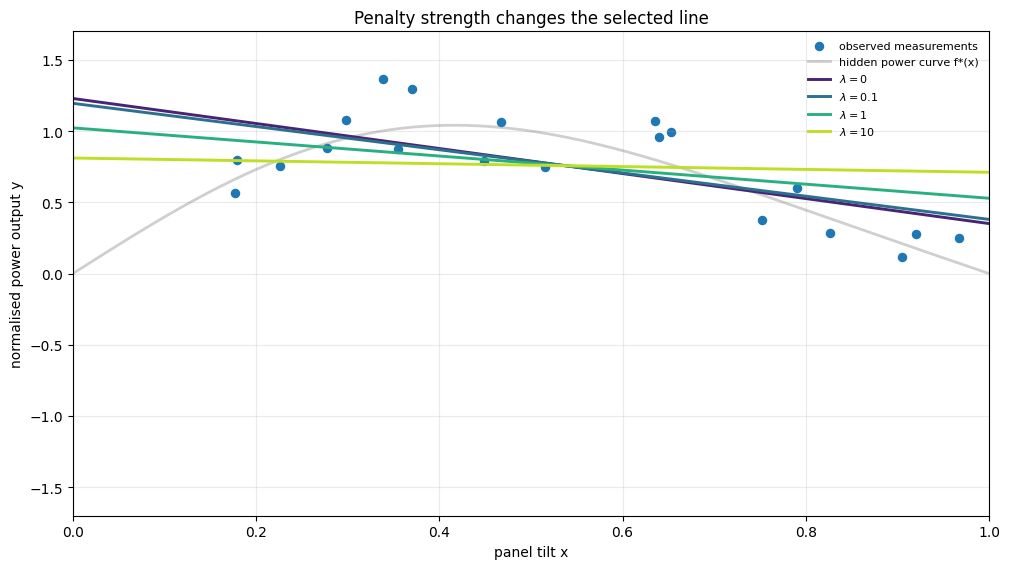

Selected degree-1 theta as the score changes
01. lambda_rss=0, theta_0=1.22860, theta_1=-0.87786, rss=1.41798, penalty=0, objective=1.41798
02. lambda_rss=0.10000, theta_0=1.19459, theta_1=-0.81455, rss=1.42314, penalty=0.06635, objective=1.48949
03. lambda_rss=1.00000, theta_0=1.02237, theta_1=-0.49394, rss=1.60762, penalty=0.24397, objective=1.85159
04. lambda_rss=10.00000, theta_0=0.81079, theta_1=-0.10007, rss=2.19629, penalty=0.10013, objective=2.29643


In [8]:
# Show how the ridge penalty changes the objective landscape in a two-parameter model.
landscape_lambdas = (0.0, 0.1, 1.0, 10.0)
theta0_values = np.linspace(-1.2, 2.2, 160)
theta1_values = np.linspace(-5.0, 2.0, 160)
Theta0, Theta1 = np.meshgrid(theta0_values, theta1_values)

landscape_surfaces = []
landscape_solutions = []
landscape_rows = []
for lambda_reg in landscape_lambdas:
    objective = np.empty_like(Theta0)
    for row in range(Theta0.shape[0]):
        for col in range(Theta0.shape[1]):
            pred = Theta0[row, col] + Theta1[row, col] * x_train_opt
            rss = np.sum((y_train_opt - pred) ** 2)
            penalty = lambda_reg * Theta1[row, col] ** 2
            objective[row, col] = rss + penalty
    landscape_surfaces.append(objective)
    if lambda_reg == 0.0:
        coeffs = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=1)
    else:
        coeffs = models.fit_polynomial_ridge_map(x_train_opt, y_train_opt, degree=1, lambda_reg=lambda_reg)
    train_pred = models.predict_polynomial(x_train_opt, coeffs)
    rss_at_solution = float(np.sum((y_train_opt - train_pred) ** 2))
    penalty_at_solution = float(lambda_reg * coeffs[1] ** 2)
    landscape_solutions.append(coeffs)
    landscape_rows.append(
        {
            "lambda_rss": lambda_reg,
            "theta_0": coeffs[0],
            "theta_1": coeffs[1],
            "rss": rss_at_solution,
            "penalty": penalty_at_solution,
            "objective": rss_at_solution + penalty_at_solution,
        }
    )

level_min = min(float(surface.min()) for surface in landscape_surfaces)
level_max = max(float(np.percentile(surface, 72)) for surface in landscape_surfaces)
levels = np.linspace(level_min, level_max, 28)

fig_landscape, axes = plt.subplots(
    1,
    len(landscape_lambdas),
    figsize=(4.2 * len(landscape_lambdas), 5.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for ax, lambda_reg, surface, coeffs in zip(axes, landscape_lambdas, landscape_surfaces, landscape_solutions):
    clipped = np.clip(surface, levels[0], levels[-1])
    contour = ax.contourf(Theta0, Theta1, clipped, levels=levels, cmap="viridis")
    ax.scatter(coeffs[0], coeffs[1], color="#e15759", s=70, edgecolor="white", label="selected theta")
    ax.axhline(0.0, color="white", linewidth=1.0, alpha=0.75)
    ax.set_title(rf"$\lambda_{{RSS}}={lambda_reg:g}$")
    ax.set_xlabel(r"$\theta_0$")
    ax.grid(alpha=0.18)
axes[0].set_ylabel(r"$\theta_1$")
axes[-1].legend(frameon=False, loc="lower right")
fig_landscape.colorbar(contour, ax=axes, label="RSS + penalty", shrink=0.85)
show_fig(fig_landscape)

fig_lines, ax_lines = plt.subplots(figsize=(10.2, 5.8))
ax_lines.scatter(x_train_opt, y_train_opt, s=34, color="#1f77b4", label="observed measurements")
ax_lines.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(landscape_lambdas)))
for color, lambda_reg, coeffs in zip(colors, landscape_lambdas, landscape_solutions):
    ax_lines.plot(x_grid, models.predict_polynomial(x_grid, coeffs), color=color, linewidth=2.1, label=rf"$\lambda={lambda_reg:g}$")
ax_lines.set_title("Penalty strength changes the selected line")
ax_lines.set_xlabel("panel tilt x")
ax_lines.set_ylabel("normalised power output y")
ax_lines.set_xlim(0.0, 1.0)
ax_lines.set_ylim(-1.7, 1.7)
ax_lines.grid(alpha=0.25)
ax_lines.legend(frameon=False, fontsize=8)
fig_lines.tight_layout()
show_fig(fig_lines)

print_rows(landscape_rows, digits=5, title="Selected degree-1 theta as the score changes")


<br>

## 9. Follow a Selection Path

Varying the penalty shows how the selected solution moves inside the same space.


The two-parameter landscape shows the idea. Now return to the flexible degree-15 polynomial space from Notebook 02.

Keep the evidence and hypothesis space fixed. Vary only $\lambda_{\text{RSS}}$. Each value defines a different optimization space and therefore a different selected parameter vector. The path below is not a search over new model classes; it is a sequence of different selection rules applied to the same available family.

Read the table as a record of how the selector changes. Training MSE reports the data-fit part of the score, the coefficient norm reports the penalty target, and the system condition reports how the numerical problem changes as the penalty stabilises the coordinates.


### 9.1 Before running: predict the ridge path

The next cell keeps $\mathcal{D}$ and $\mathcal{H}$ fixed and varies only $\lambda$. Fill this table before running.

| As $\lambda$ increases... | Prediction |
|---|---|
| Training MSE | |
| Coefficient norm | |
| Curve smoothness/stability | |
| Condition number | |


In [9]:
# Keep the fitting data and degree fixed, then change only the regularisation strength.
ridge_degree = 15
lambdas = np.r_[0.0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_rows = []
ridge_fits = {}
Phi_ridge = models.polynomial_features(x_train_opt, degree=ridge_degree)
R = np.eye(ridge_degree + 1)
R[0, 0] = 0.0

for lambda_reg in lambdas:
    if lambda_reg == 0.0:
        # Use the stable least-squares path for the unregularised baseline.
        coeffs = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=ridge_degree)
    else:
        coeffs = models.fit_polynomial_ridge_map(
            x_train_opt,
            y_train_opt,
            degree=ridge_degree,
            lambda_reg=lambda_reg,
        )
    train_pred = models.predict_polynomial(x_train_opt, coeffs)
    residual_sum_squares = float(np.sum((y_train_opt - train_pred) ** 2))
    penalty = float(lambda_reg * np.sum(coeffs[1:] ** 2))
    system_matrix = Phi_ridge.T @ Phi_ridge + lambda_reg * R
    ridge_rows.append(
        {
            "lambda_rss": lambda_reg,
            "lambda_mse_equiv": lambda_reg / len(y_train_opt),
            "train_mse": metrics.mse(y_train_opt, train_pred),
            "data_sse": residual_sum_squares,
            "penalty": penalty,
            "penalized_coef_norm": np.linalg.norm(coeffs[1:]),
            "system_condition": np.linalg.cond(system_matrix),
        }
    )
    ridge_fits[float(lambda_reg)] = coeffs

print_rows(ridge_rows, digits=5, title=f"Degree {ridge_degree} with different objective penalties")


Degree 15 with different objective penalties
01. lambda_rss=0, lambda_mse_equiv=0, train_mse=0.00977, data_sse=0.19534, penalty=0, penalized_coef_norm=5.14e+11, system_condition=8.59e+17
02. lambda_rss=0.00100, lambda_mse_equiv=0.00005, train_mse=0.02924, data_sse=0.58488, penalty=0.01508, penalized_coef_norm=3.88363, system_condition=3.82e+04
03. lambda_rss=0.01000, lambda_mse_equiv=0.00050, train_mse=0.03079, data_sse=0.61577, penalty=0.05494, penalized_coef_norm=2.34396, system_condition=3825.05959
04. lambda_rss=0.10000, lambda_mse_equiv=0.00500, train_mse=0.03847, data_sse=0.76946, penalty=0.10737, penalized_coef_norm=1.03621, system_condition=383.45447
05. lambda_rss=1.00000, lambda_mse_equiv=0.05000, train_mse=0.04933, data_sse=0.98656, penalty=0.11616, penalized_coef_norm=0.34082, system_condition=39.62253
06. lambda_rss=10.00000, lambda_mse_equiv=0.50000, train_mse=0.06422, data_sse=1.28430, penalty=0.33997, penalized_coef_norm=0.18438, system_condition=5.96775
07. lambda_rss=

<br>

## 10. Preview the Regularisation Trade-off

The ridge path makes the fit-versus-restraint trade-off visible.


The table above shows the selected $\lambda_{\mathrm{RSS}}$ path used in the plots. The next cell reuses those same penalty strengths so the table, selected curves, and diagnostic plots all describe the same selector path.

Read the figure as three linked views of the same change to $\mathcal{O}$:

1. the first plot shows several selected curves from the same $\mathcal{H}$;
2. the second plot compares training MSE with a held-out measurement sample on log-scaled axes; and
3. the third plot shows the non-intercept coefficient norm that ridge is trying to shrink, also on a log-scaled y-axis.

The held-out sample is a Notebook 04 preview only. It is not used by the optimizer and it is not cross-validation. Its role here is to make one limitation visible: winning the training objective is not the same as travelling well to fresh evidence.


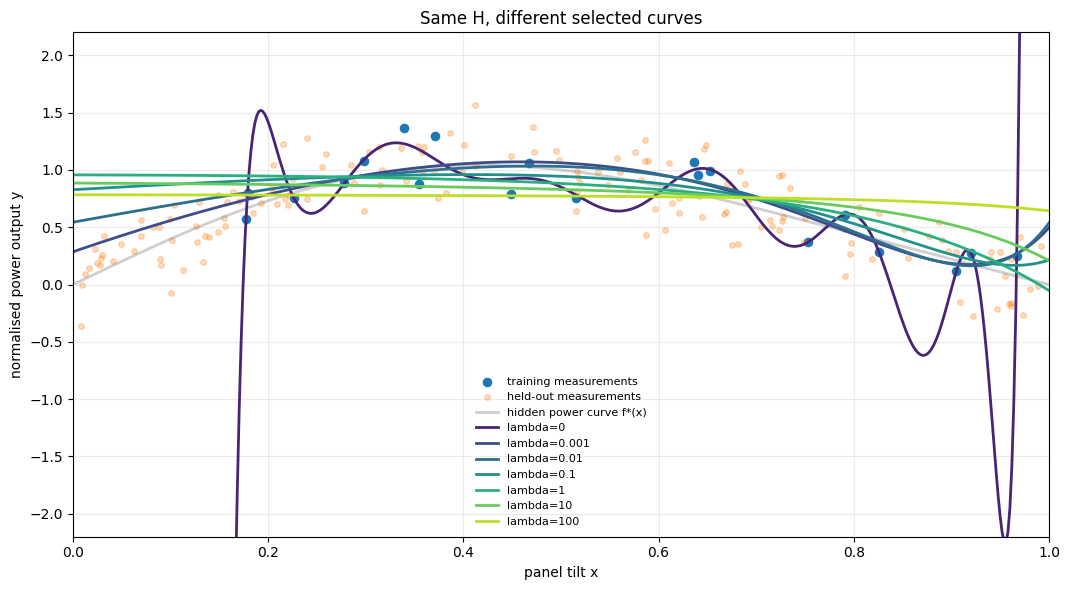

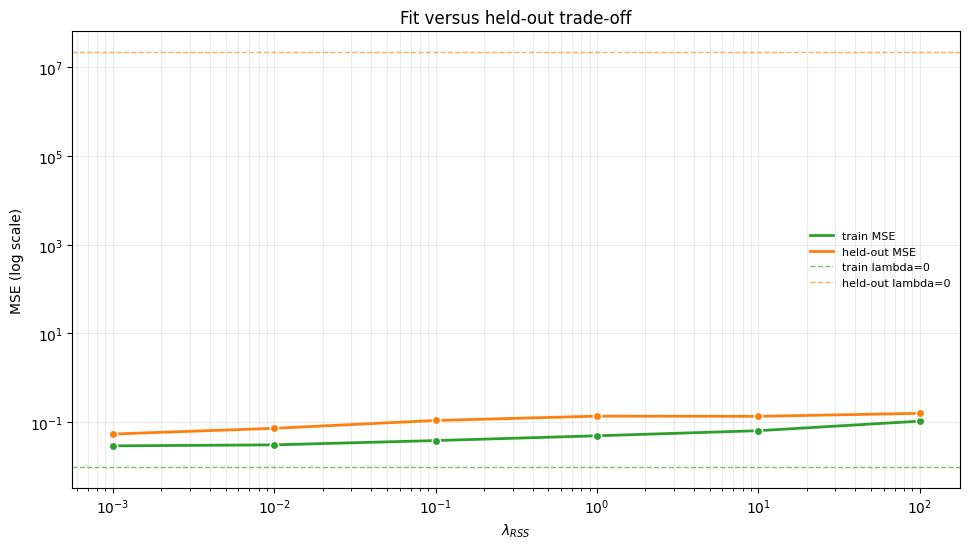

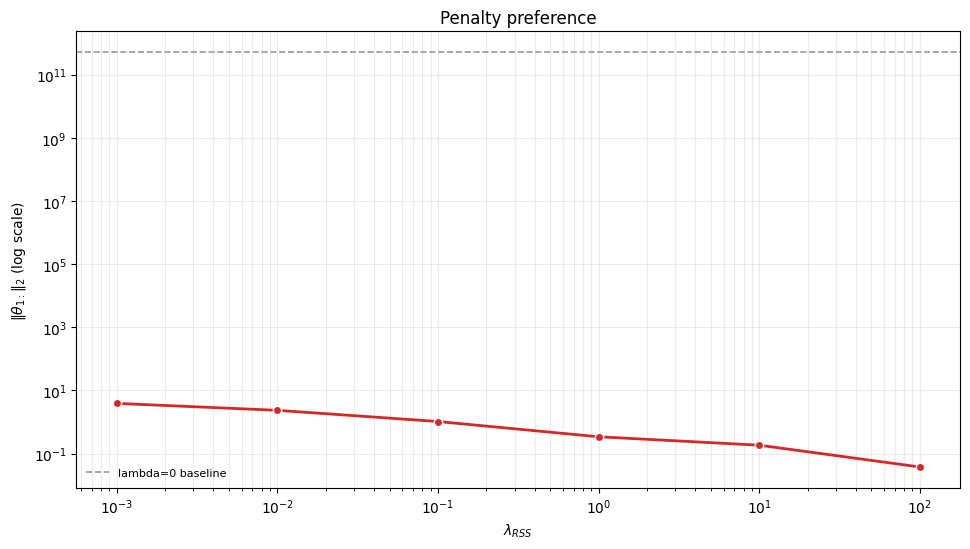

Held-out preview of the regularisation trade-off
01. best_lambda_by_heldout_mse=0.00100, train_mse_at_best=0.02924, heldout_mse_at_best=0.05397, lambda_0_train_mse=0.00977, lambda_0_heldout_mse=2.20e+07


In [10]:
# Visualise selected curves and the train/held-out trade-off across lambda values.
# The held-out sample previews Notebook 04: it is not used by the optimizer.
x_test_opt, y_test_opt = data.make_regression_data(
    n=160,
    noise_std=noise_std,
    seed=seed + 1,
    sampling=sampling,
)

path_lambdas = np.asarray(lambdas, dtype=float)
path_train_mse = []
path_test_mse = []
path_coef_norm = []
path_data_sse = []
path_penalty = []
path_coeffs = {}

for lambda_reg in path_lambdas:
    if lambda_reg == 0.0:
        coeffs = models.fit_polynomial_mle(x_train_opt, y_train_opt, degree=ridge_degree)
    else:
        coeffs = models.fit_polynomial_ridge_map(
            x_train_opt,
            y_train_opt,
            degree=ridge_degree,
            lambda_reg=lambda_reg,
        )
    train_pred = models.predict_polynomial(x_train_opt, coeffs)
    test_pred = models.predict_polynomial(x_test_opt, coeffs)
    data_sse = float(np.sum((y_train_opt - train_pred) ** 2))
    coef_norm = float(np.linalg.norm(coeffs[1:]))
    path_train_mse.append(metrics.mse(y_train_opt, train_pred))
    path_test_mse.append(metrics.mse(y_test_opt, test_pred))
    path_coef_norm.append(coef_norm)
    path_data_sse.append(data_sse)
    path_penalty.append(float(lambda_reg * coef_norm**2))
    path_coeffs[float(lambda_reg)] = coeffs

positive_mask = path_lambdas > 0
positive_lambdas = path_lambdas[positive_mask]
train_curve = np.array(path_train_mse)[positive_mask]
test_curve = np.array(path_test_mse)[positive_mask]
norm_curve = np.array(path_coef_norm)[positive_mask]
selected_positive_lambdas = [float(row["lambda_rss"]) for row in ridge_rows if row["lambda_rss"] > 0]
selected_train_mse = [row["train_mse"] for row in ridge_rows if row["lambda_rss"] > 0]
selected_test_mse = [
    metrics.mse(y_test_opt, models.predict_polynomial(x_test_opt, ridge_fits[float(row["lambda_rss"])]))
    for row in ridge_rows
    if row["lambda_rss"] > 0
]
selected_norms = [row["penalized_coef_norm"] for row in ridge_rows if row["lambda_rss"] > 0]

fig_curve, ax_curve = plt.subplots(figsize=(10.8, 6.0))
ax_curve.scatter(x_train_opt, y_train_opt, s=35, color="#1f77b4", label="training measurements")
ax_curve.scatter(x_test_opt, y_test_opt, s=16, color="#ff7f0e", alpha=0.28, label="held-out measurements")
ax_curve.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(path_lambdas)))
for color, lambda_reg in zip(colors, path_lambdas):
    curve = models.predict_polynomial(x_grid, path_coeffs[float(lambda_reg)])
    ax_curve.plot(x_grid, curve, color=color, linewidth=2.0, label=f"lambda={lambda_reg:g}")
ax_curve.set_title("Same H, different selected curves")
ax_curve.set_xlabel("panel tilt x")
ax_curve.set_ylabel("normalised power output y")
ax_curve.set_xlim(0.0, 1.0)
ax_curve.set_ylim(-2.2, 2.2)
ax_curve.grid(alpha=0.25)
ax_curve.legend(frameon=False, fontsize=8)
fig_curve.tight_layout()
show_fig(fig_curve)

fig_mse, ax_mse = plt.subplots(figsize=(9.8, 5.6))
ax_mse.semilogx(positive_lambdas, train_curve, color="#2ca02c", linewidth=2.0, label="train MSE")
ax_mse.semilogx(positive_lambdas, test_curve, color="#ff7f0e", linewidth=2.0, label="held-out MSE")
ax_mse.scatter(selected_positive_lambdas, selected_train_mse, color="#2ca02c", edgecolor="white", zorder=3)
ax_mse.scatter(selected_positive_lambdas, selected_test_mse, color="#ff7f0e", edgecolor="white", zorder=3)
ax_mse.axhline(path_train_mse[0], color="#2ca02c", linestyle="--", linewidth=1.0, alpha=0.65, label="train lambda=0")
ax_mse.axhline(path_test_mse[0], color="#ff7f0e", linestyle="--", linewidth=1.0, alpha=0.65, label="held-out lambda=0")
ax_mse.set_yscale("log")
ax_mse.set_title("Fit versus held-out trade-off")
ax_mse.set_xlabel(r"$\lambda_{RSS}$")
ax_mse.set_ylabel("MSE (log scale)")
ax_mse.grid(alpha=0.25, which="both")
ax_mse.legend(frameon=False, fontsize=8)
fig_mse.tight_layout()
show_fig(fig_mse)

fig_norm, ax_norm = plt.subplots(figsize=(9.8, 5.6))
ax_norm.semilogx(positive_lambdas, norm_curve, color="#d62728", linewidth=2.0)
ax_norm.scatter(selected_positive_lambdas, selected_norms, color="#d62728", edgecolor="white", zorder=3)
ax_norm.axhline(path_coef_norm[0], color="#999999", linestyle="--", linewidth=1.2, label="lambda=0 baseline")
ax_norm.set_yscale("log")
ax_norm.set_title("Penalty preference")
ax_norm.set_xlabel(r"$\lambda_{RSS}$")
ax_norm.set_ylabel(r"$\Vert\theta_{1:}\Vert_2$ (log scale)")
ax_norm.grid(alpha=0.25, which="both")
ax_norm.legend(frameon=False, fontsize=8)
fig_norm.tight_layout()
show_fig(fig_norm)

best_idx = int(np.argmin(path_test_mse))
print_rows(
    [
        {
            "best_lambda_by_heldout_mse": path_lambdas[best_idx],
            "train_mse_at_best": path_train_mse[best_idx],
            "heldout_mse_at_best": path_test_mse[best_idx],
            "lambda_0_train_mse": path_train_mse[0],
            "lambda_0_heldout_mse": path_test_mse[0],
        }
    ],
    digits=5,
    title="Held-out preview of the regularisation trade-off",
)


### 10.1 After running: diagnose the regularisation trade-off

The ridge path shows a sequence of selected solutions from the same raw hypothesis space.

- Low $\lambda$ values prioritise fitting the observed rows.
- High $\lambda$ values make large coefficients expensive.
- The log-scaled diagnostic plots make multiplicative changes in error and coefficient norm easier to read across the wide $\lambda$ range.
- The selected curve moves because the optimization space changed, not because the data or model family changed.

Regularisation is a solution-selection preference. It is one way to control what parts of a rich hypothesis space are cheap or expensive for the optimizer to choose.


<br>

## 11. Summary: What $\mathcal{O}$ Adds and What It Cannot Prove

Optimization selects a solution, but it does not prove the solution will generalise.


The data stayed fixed. The degree-15 space stayed available. The selected function changed because the selection rule changed.

1. **Loss defines fit.** MSE values squared residuals on $\mathcal{D}$. Another loss can select another solution.
2. **Minimisation turns scores into a solution.** Least squares chooses the lowest training score, not the truest curve.
3. **Penalties add preferences.** Ridge values fit and smaller coefficients.
4. **Solvers implement the selector.** Closed-form formulas are convenient here; later models often need iterative algorithms.
5. **Held-out checks are separate.** The held-out plot previews Notebook 04. It is not used by the optimizer.

$\mathcal{O}$ can choose from $\mathcal{H}$ using $\mathcal{D}$ and encode preferences such as smaller coefficients. It cannot prove that the selected rule will be trustworthy. Notebook 04 asks where the selected function is actually supported.


<br>

## 12. Optimization-space diagnostic checklist

Use the checklist to inspect losses, penalties, solvers, scaling, and validation use.


When a selected solution looks surprising, ask:

| Diagnostic | Question |
|---|---|
| Loss | What errors does the objective reward or punish? |
| Penalty/prior | What solutions are made cheaper or more expensive? |
| Solver | Did the numerical method reliably reach the intended solution? |
| Scaling/conditioning | Is the coordinate system making selection unstable? |
| Validation use | Was fresh evidence used to choose settings, or only to check them? |

**Takeaway.** $\mathcal{O}$ selects a solution from $\mathcal{H}$ using $\mathcal{D}$. It does not by itself prove that the selected solution will generalise.


<br>

## 13. Bridge to Notebook 04

After selection, the next question is whether the selected rule can be trusted.


We now have the three ingredients that produce a fitted rule: available hypotheses $h_\theta\in\mathcal{H}$, observed evidence $\mathcal{D}$, and an optimization space $\mathcal{O}$ that chooses a parameter value $\hat{\theta}\in\Theta$.

Notebook 03 made selection explicit:

$$
(\mathcal{H},\mathcal{D},\mathcal{O}) \longmapsto s.
$$

But selection is not the same as trust. A curve can be the best candidate under the chosen score and still fail in regions that were sparse, noisy, or held out from selection.

Notebook 04 changes the question from "which candidate did the selector choose?" to "where should that selected rule travel?" That is the generalisation question.


<br>

## 14. References

These references support the optimization, least-squares, and regularisation ideas used here.


References for convex quadratic objectives, numerical least squares, ridge regression, and the MAP interpretation.

- Boyd, S., & Vandenberghe, L. (2004). [*Convex Optimization*](https://www.cambridge.org/highereducation/books/convex-optimization/17D2FAA54F641A2F62C7CCD01DFA97C4). Convex objectives, quadratic geometry, and uniqueness of minimisers.
- Björck, Å. (1996). [*Numerical Methods for Least Squares Problems*](https://epubs.siam.org/doi/10.1137/1.9781611971484). Least-squares computation, normal equations, QR/SVD methods, rank deficiency, and regularisation.
- Hoerl, A. E., & Kennard, R. W. (1970). [*Ridge Regression: Biased Estimation for Nonorthogonal Problems*](https://www.tandfonline.com/doi/abs/10.1080/00401706.1970.10488634), *Technometrics*, 12(1), 55-67. Original ridge-regression motivation for stabilising nonorthogonal regression problems.
- Bishop, C. M. (2006). [*Pattern Recognition and Machine Learning*](https://link.springer.com/book/9780387310732). Gaussian likelihoods, Gaussian parameter priors, and MAP estimation.
